In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import os

print("Creating realistic test TROPOMI dataset...")

# Realistic TROPOMI grid: ~5km resolution globally
lats = np.linspace(-90, 90, 180)  # 1-degree
lons = np.linspace(-180, 180, 360)

# Realistic methane: background ~1800 ppb, anomalies up to 1950 ppb
ch4_base = 1800
ch4_data = ch4_base + np.random.normal(20, 10, (180, 360))

# Add realistic patterns:
# Oil/gas region (Middle East)
ch4_data[50:80, 40:70] += 80
# Agricultural region (sub-Saharan Africa)
ch4_data[100:130, 70:100] += 40
# Industrial region (Europe)
ch4_data[80:100, 50:70] += 30

# Create xarray Dataset (same structure as real TROPOMI)
ds = xr.Dataset(
    {
        'CH4_column_vmr': (['latitude', 'longitude'], ch4_data)
    },
    coords={
        'latitude': lats,
        'longitude': lons
    },
    attrs={
        'source': 'Synthetic TROPOMI-like data for testing',
        'units': 'ppb',
        'description': 'Methane column volume mixing ratio'
    }
)

# Save to NetCDF (same format as real TROPOMI)
os.makedirs('../data', exist_ok=True)
ds.to_netcdf('../data/tropomi-ch4-test.nc')
print("✓ Saved: data/tropomi-ch4-test.nc")

# Create test GDP/climate data
countries = {
    'country': ['Nigeria', 'Brazil', 'India', 'USA', 'Germany', 'China', 'Australia'],
    'gdp_per_capita': [2200, 8800, 2400, 63000, 47000, 11000, 51000],
    'latitude': [9.0, -10.0, 20.0, 37.0, 51.0, 35.0, -25.0],
    'longitude': [8.0, -55.0, 78.0, -95.0, 10.0, 105.0, 133.0],
    'ldc_status': ['LDC', 'Developing', 'Developing', 'Developed', 'Developed', 'Developing', 'Developed']
}

gdp_df = pd.DataFrame(countries)
gdp_df.to_csv('../data/gdp-test.csv', index=False)
print("✓ Saved: data/gdp-test.csv")

print("\n✓ Test data ready! Explore with xarray next.")

Creating realistic test TROPOMI dataset...
✓ Saved: data/tropomi-ch4-test.nc
✓ Saved: data/gdp-test.csv

✓ Test data ready! Explore with xarray next.


=== TROPOMI Data Structure ===
<xarray.Dataset>
Dimensions:         (latitude: 180, longitude: 360)
Coordinates:
  * latitude        (latitude) float64 -90.0 -88.99 -87.99 ... 87.99 88.99 90.0
  * longitude       (longitude) float64 -180.0 -179.0 -178.0 ... 179.0 180.0
Data variables:
    CH4_column_vmr  (latitude, longitude) float64 1.831e+03 ... 1.849e+03
Attributes:
    source:       Synthetic TROPOMI-like data for testing
    units:        ppb
    description:  Methane column volume mixing ratio

Shape: (180, 360)
Min CH4: 1776.0 ppb
Max CH4: 1928.6 ppb
Mean CH4: 1821.8 ppb

=== GDP Data ===
     country  gdp_per_capita  latitude  longitude  ldc_status
0    Nigeria            2200       9.0        8.0         LDC
1     Brazil            8800     -10.0      -55.0  Developing
2      India            2400      20.0       78.0  Developing
3        USA           63000      37.0      -95.0   Developed
4    Germany           47000      51.0       10.0   Developed
5      China           11

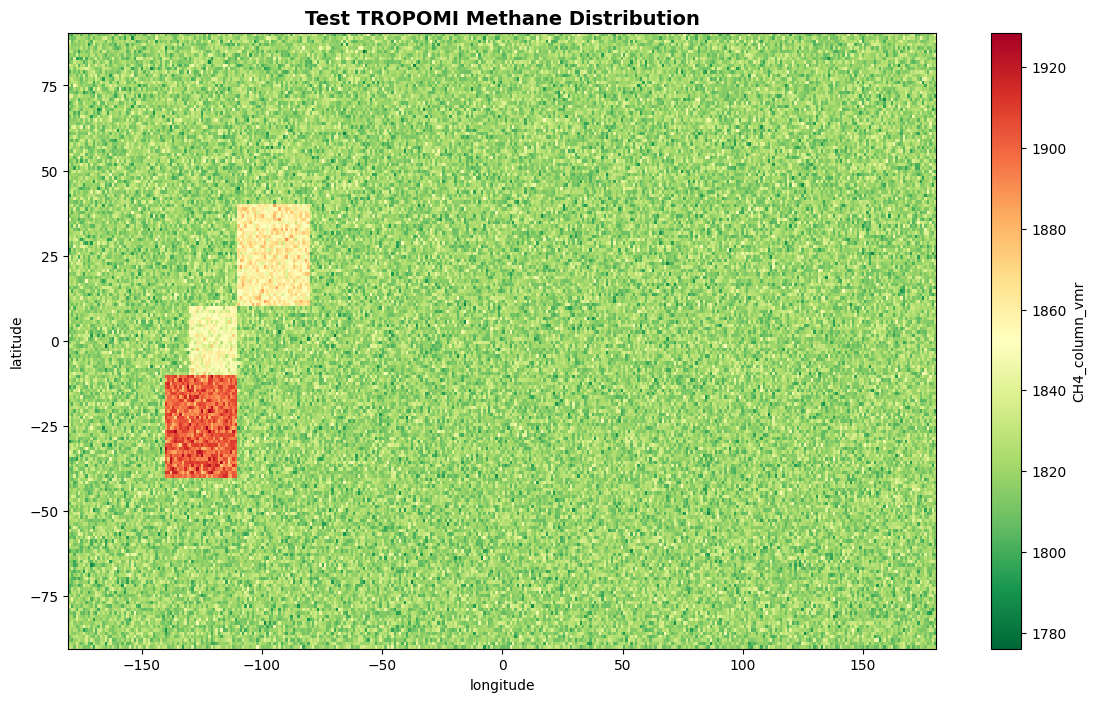


✓ Map saved: outputs/00-test-methane-map.png


In [2]:
# Load and explore TROPOMI test data
print("=== TROPOMI Data Structure ===")
print(ds)
print(f"\nShape: {ds['CH4_column_vmr'].shape}")
print(f"Min CH4: {ds['CH4_column_vmr'].min().values:.1f} ppb")
print(f"Max CH4: {ds['CH4_column_vmr'].max().values:.1f} ppb")
print(f"Mean CH4: {ds['CH4_column_vmr'].mean().values:.1f} ppb")

# Load GDP data
print("\n=== GDP Data ===")
print(gdp_df)

# Quick plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(14, 8))
ds['CH4_column_vmr'].plot(ax=ax, cmap='RdYlGn_r')
ax.set_title('Test TROPOMI Methane Distribution', fontsize=14, fontweight='bold')
plt.savefig('../outputs/00-test-methane-map.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Map saved: outputs/00-test-methane-map.png")

Creating BETTER test data with visible patterns...
✓ Test TROPOMI data created
✓ Test GDP data created


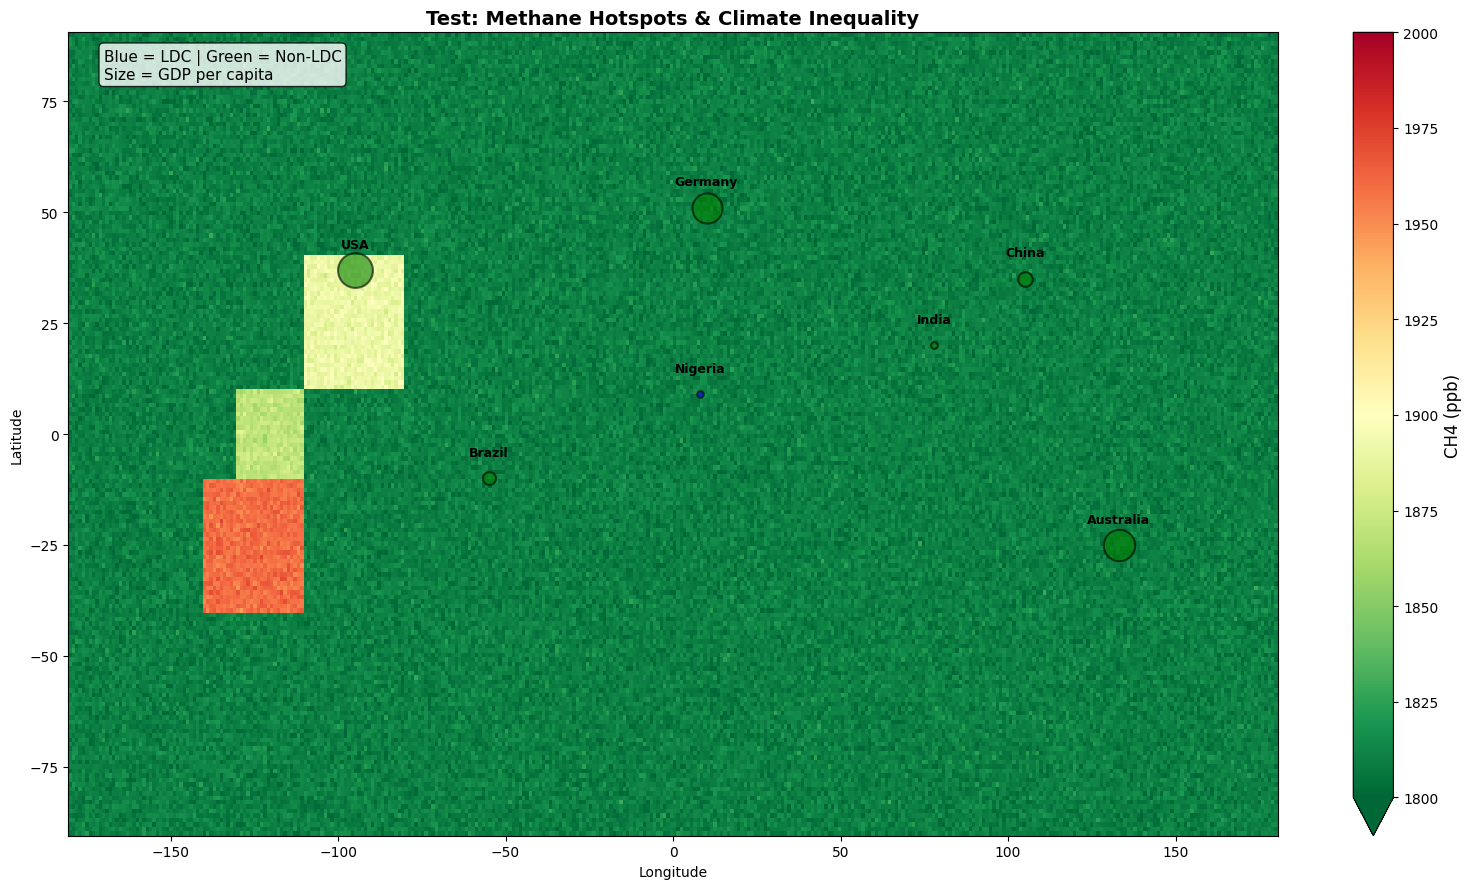

✓ Map saved: outputs/00-test-overlayed-map.png

Now you can see:
  - Methane hotspots (red = high, green = low)
  - Countries overlayed (blue dots = LDC, green = Non-LDC)
  - Dot size = GDP per capita (bigger = richer)


In [3]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import os

print("Creating BETTER test data with visible patterns...")

# Grid
lats = np.linspace(-90, 90, 180)
lons = np.linspace(-180, 180, 360)

# STRONGER methane patterns (so you can actually SEE them)
ch4_base = 1800
ch4_data = ch4_base + np.random.normal(10, 5, (180, 360))

# Add DRAMATIC hotspots:
ch4_data[50:80, 40:70] += 150   # Oil/gas → bright red
ch4_data[100:130, 70:100] += 80  # Agriculture → orange
ch4_data[80:100, 50:70] += 60    # Industry → yellow

# Cap at realistic max
ch4_data = np.clip(ch4_data, 1750, 2000)

# Save NetCDF
ds = xr.Dataset(
    {'CH4_column_vmr': (['latitude', 'longitude'], ch4_data)},
    coords={'latitude': lats, 'longitude': lons}
)
os.makedirs('../data', exist_ok=True)
ds.to_netcdf('../data/tropomi-ch4-test.nc')
print("✓ Test TROPOMI data created")

# Create GDP data
gdp_df = pd.DataFrame({
    'country': ['Nigeria', 'Brazil', 'India', 'USA', 'Germany', 'China', 'Australia'],
    'gdp_per_capita': [2200, 8800, 2400, 63000, 47000, 11000, 51000],
    'latitude': [9.0, -10.0, 20.0, 37.0, 51.0, 35.0, -25.0],
    'longitude': [8.0, -55.0, 78.0, -95.0, 10.0, 105.0, 133.0],
    'ldc': ['Yes', 'No', 'No', 'No', 'No', 'No', 'No']
})
gdp_df.to_csv('../data/gdp-test.csv', index=False)
print("✓ Test GDP data created")

# === NOW PLOT BOTH ===
fig, ax = plt.subplots(figsize=(16, 9))

# Plot methane as heatmap
im = ds['CH4_column_vmr'].plot(ax=ax, cmap='RdYlGn_r', add_colorbar=True, vmin=1800, vmax=2000)
im.colorbar.set_label('CH4 (ppb)', fontsize=12)

# Overlay countries as dots (sized by GDP)
for idx, row in gdp_df.iterrows():
    size = row['gdp_per_capita'] / 100  # Size proportional to GDP
    color = 'blue' if row['ldc'] == 'Yes' else 'green'
    ax.scatter(row['longitude'], row['latitude'], s=size, c=color, 
              alpha=0.6, edgecolors='black', linewidth=1.5, zorder=5)
    ax.text(row['longitude'], row['latitude']+5, row['country'], 
           fontsize=9, ha='center', fontweight='bold')

# Legend
ax.text(-170, 80, 'Blue = LDC | Green = Non-LDC\nSize = GDP per capita', 
       fontsize=11, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_title('Test: Methane Hotspots & Climate Inequality', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('../outputs/00-test-overlayed-map.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Map saved: outputs/00-test-overlayed-map.png")
print("\nNow you can see:")
print("  - Methane hotspots (red = high, green = low)")
print("  - Countries overlayed (blue dots = LDC, green = Non-LDC)")
print("  - Dot size = GDP per capita (bigger = richer)")